# Modelo diario de viento térmico S/SO ≥ 10 kt — Badalona

**Objetivo:** predecir si un día habrá viento de dirección **Sur / Suroeste** con **media ≥ 10 nudos** en el spot BDLONA.

**Dataset base:** `../data/gold/featured_dataset_v1.parquet`

**Corrección clave respecto al modelo anterior:**
- `Night_Day_Gradient` = máxima − mínima de `air_temperature` **de todo el día** (24 h), no min/max horarios de XEMA.
- `Air_See_Gradient` diario = **máximo** del gradiente horario (`air_temperature − sst`), no la media.


### 1. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


### 2. Configuración


In [2]:
# --- Rutas ---
DATA_PATH = "../data/gold/featured_dataset_v1.parquet"
HOURLY_OUT = "../data/gold/hourly_model_v2.parquet"
DAILY_OUT = "../data/gold/daily_model_v2.parquet"
REPORT_DIR = "../reports"

# --- Definición meteorológica del target ---
WIND_SPEED_MIN_KT = 10          # media mínima en nudos
DIR_MIN_DEG = 135               # Sur (aprox.)
DIR_MAX_DEG = 225               # Suroeste (aprox.)

# --- Split temporal (igual que notebook 07) ---
TRAIN_END = "2021-12-31"
VALID_START = "2022-01-01"
VALID_END = "2023-12-31"
TEST_START = "2024-01-01"

RANDOM_STATE = 42


### 3. Carga del dataset

El parquet tiene índice horario (`DatetimeIndex`) y 61 columnas originales.


In [3]:
df = pd.read_parquet(DATA_PATH)

if not isinstance(df.index, pd.DatetimeIndex):
    df = df.set_index("datetime")

df = df.sort_index()

print(f"Registros: {len(df):,}")
print(f"Rango: {df.index.min()} → {df.index.max()}")
print(f"Columnas: {len(df.columns)}")
df.head(3)


Registros: 140,256
Rango: 2010-01-01 00:00:00 → 2025-12-31 23:00:00
Columnas: 61


,Temperatura,Temperatura màxima,Temperatura mínima,Humitat relativa,Humitat relativa màxima,Humitat relativa mínima,Pressió atmosfèrica,Pressió atmosfèrica mínima,Velocitat del vent a 6 m (esc.),Ratxa màxima del vent a 6 m,Precipitació,Precipitació màxima en 1 minut,Irradiància solar global,wind_u,wind_v,sst,sst_original,wave_height,wave_height_h13,wave_period_mean,wave_period_tm02,wave_peak_period,wave_max_period,wave_direction,wave_peak_direction,wave_angular_spread,sst_roll_6h,sst_roll_24h,sst_delta_3h,sst_delta_24h,temperature,wind_direction_deg,wind_avg,wind_min,wind_max,month,hour,is_operational_hour,wind_data_available,valid_wind_observation,operational_gap,day_of_year,season,hour_sin,hour_cos,doy_sin,doy_cos,pressure_tendency_3h,pressure_tendency_6h,air_temp_combined,coastal_inland_temp_diff,land_sea_temp_gradient,thermal_wind_flag,thermal_event,sailable_wind,daily_temp_range,solar_roll_3h,solar_roll_6h,sst_climatology,sst_anomaly,solar_gradient_interaction
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2010-01-01 00:00:00,11.8,12.1,11.3,48.0,49.0,46.0,989.5,989.0,7.40,16.900000,0.2,0.2,0.0,-1.852812,-7.164292,14.0,14.0,2.05,1.84,5.55,5.14,6.65,6.78,210.0,210.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0,0,1,1,0.000000,1.000000,0.017213,0.999852,NaN,NaN,11.8,NaN,-2.2,False,0,0,3.725001,NaN,NaN,NaN,NaN,-0.0
2010-01-01 01:00:00,10.9,11.3,10.3,49.0,51.0,47.0,990.0,989.0,7.80,17.200001,0.0,0.0,0.0,-0.611981,-7.775955,14.0,14.0,1.88,1.78,5.53,5.06,7.13,7.00,213.0,205.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,0,0,1,1,0.258819,0.965926,0.017213,0.999852,NaN,NaN,10.9,NaN,-3.1,False,0,0,3.725001,NaN,NaN,NaN,NaN,-0.0
2010-01-01 02:00:00,10.3,10.3,10.2,49.5,51.0,48.0,990.0,989.0,7.95,15.900000,0.0,0.0,0.0,-0.208105,-7.947276,14.0,14.0,1.95,1.84,5.76,5.02,7.13,7.67,217.0,219.0,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2,0,0,0,0,1,1,0.500000,0.866025,0.017213,0.999852,NaN,NaN,10.3,NaN,-3.7,False,0,0,3.725001,0.0,NaN,NaN,NaN,-0.0


### 4. Selección de columnas y renombrado

Solo mantenemos las variables acordadas.


In [4]:
COLUMN_RENAME = {
    "air_temp_combined": "air_temperature",
    "sailable_wind": "Wind_Over_10Kt",
}

KEEP_COLUMNS = [
    "air_temp_combined",
    "wind_direction_deg",
    "wind_avg",
    "wind_max",
    "wind_min",
    "sst",
    "month",
    "hour",
    "wind_data_available",
    "valid_wind_observation",
    "operational_gap",
    "day_of_year",
    "season",
    "sailable_wind",
    "Pressió atmosfèrica",
    "Precipitació",
    "Irradiància solar global",
]

missing = [c for c in KEEP_COLUMNS if c not in df.columns]
if missing:
    raise ValueError(f"Columnas no encontradas en el parquet: {missing}")

hourly = (
    df[KEEP_COLUMNS]
    .rename(columns=COLUMN_RENAME)
    .copy()
)

hourly.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 140256 entries, 2010-01-01 00:00:00 to 2025-12-31 23:00:00
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   air_temperature           140155 non-null  float64
 1   wind_direction_deg        72947 non-null   float64
 2   wind_avg                  72947 non-null   float64
 3   wind_max                  72947 non-null   float64
 4   wind_min                  72947 non-null   float64
 5   sst                       139262 non-null  float64
 6   month                     140256 non-null  int32  
 7   hour                      140256 non-null  int32  
 8   wind_data_available       140256 non-null  int8   
 9   valid_wind_observation    140256 non-null  int8   
 10  operational_gap           140256 non-null  int8   
 11  day_of_year               140256 non-null  int32  
 12  season                    140256 non-null  int32  
 13  Wind_Over_10Kt       

### 5. Features calculadas (nivel horario)

| Variable | Fórmula |
|---|---|
| `Air_See_Gradient` | `air_temperature − sst` |
| `Night_Day_Gradient` | max diario − min diario de `air_temperature` (24 h) |
| `Irradiancia_solar_max_dia` | máximo diario de irradiancia (replicado en cada hora) |


In [5]:
# Gradiente aire-mar horario
hourly["Air_See_Gradient"] = hourly["air_temperature"] - hourly["sst"]

# Clave de día calendario (incluye horas nocturnas de XEMA)
day_key = hourly.index.normalize()

# Night_Day_Gradient CORRECTO: max/min del dia completo sobre air_temperature
_daily_tmax = hourly.groupby(day_key)["air_temperature"].transform("max")
_daily_tmin = hourly.groupby(day_key)["air_temperature"].transform("min")
hourly["Night_Day_Gradient"] = _daily_tmax - _daily_tmin

# Máxima irradiancia del día (broadcast a cada hora)
hourly["Irradiancia_solar_max_dia"] = (
    hourly.groupby(day_key)["Irradiància solar global"].transform("max")
)

hourly[[
    "air_temperature", "sst", "Air_See_Gradient",
    "Night_Day_Gradient", "Irradiancia_solar_max_dia"
]].head(24)


,air_temperature,sst,Air_See_Gradient,Night_Day_Gradient,Irradiancia_solar_max_dia
datetime,,,,,
2010-01-01 00:00:00,11.800000,14.0,-2.200000,3.725001,1141.0
2010-01-01 01:00:00,10.900000,14.0,-3.100000,3.725001,1141.0
2010-01-01 02:00:00,10.300000,14.0,-3.700000,3.725001,1141.0
2010-01-01 03:00:00,9.850000,14.0,-4.150000,3.725001,1141.0
2010-01-01 04:00:00,9.500000,14.0,-4.500000,3.725001,1141.0
2010-01-01 05:00:00,9.500000,14.0,-4.500000,3.725001,1141.0
2010-01-01 06:00:00,9.450000,13.9,-4.450000,3.725001,1141.0
2010-01-01 07:00:00,9.299999,14.0,-4.700001,3.725001,1141.0
2010-01-01 08:00:00,10.300000,13.9,-3.600000,3.725001,1141.0


### 6. Comprobación: error del modelo anterior vs corrección

El enfoque incorrecto usaba la **media** del gradiente horario al pasar a diario.
Para el térmico nos interesa el **pico** de contraste aire-mar en la ventana diurna.


In [6]:
compare = pd.DataFrame(index=sorted(day_key.unique()))
compare["Air_See_Gradient_mean_incorrecto"] = hourly["Air_See_Gradient"].groupby(day_key).mean()
compare["Air_See_Gradient_max_correcto"] = hourly["Air_See_Gradient"].groupby(day_key).max()
compare["diferencia"] = compare["Air_See_Gradient_max_correcto"] - compare["Air_See_Gradient_mean_incorrecto"]

print(compare["diferencia"].describe())

compare.loc["2010-06-01":"2010-06-05"].head()


count    5807.000000
mean        2.271512
std         0.925200
min         0.268750
25%         1.587847
50%         2.087500
75%         2.845660
max         6.367709
Name: diferencia, dtype: float64


,Air_See_Gradient_mean_incorrecto,Air_See_Gradient_max_correcto,diferencia
2010-06-01,1.257292,2.500000,1.242709
2010-06-02,0.348958,1.600000,1.251042
2010-06-03,0.618750,2.175000,1.556250
2010-06-04,2.317262,3.700000,1.382738
2010-06-05,2.899851,4.546429,1.646578


### 7. Dataset horario enriquecido (guardar)


In [7]:
hourly.to_parquet(HOURLY_OUT)
print(f"Guardado: {HOURLY_OUT}")
print(f"Shape horario: {hourly.shape}")
hourly.columns.tolist()


Guardado: ../data/gold/hourly_model_v2.parquet
Shape horario: (140256, 20)


['air_temperature',
 'wind_direction_deg',
 'wind_avg',
 'wind_max',
 'wind_min',
 'sst',
 'month',
 'hour',
 'wind_data_available',
 'valid_wind_observation',
 'operational_gap',
 'day_of_year',
 'season',
 'Wind_Over_10Kt',
 'Pressió atmosfèrica',
 'Precipitació',
 'Irradiància solar global',
 'Air_See_Gradient',
 'Night_Day_Gradient',
 'Irradiancia_solar_max_dia']

### 8. Agregación diaria para ML

**Target diario:** ¿hubo al menos 1 observación válida con viento ≥ 10 kt y dirección S/SO?

**Features diarias:** gradientes corregidos + meteorología agregada.


In [8]:
# Flag horario del evento que queremos predecir
hourly["thermal_ssw_10kt"] = (
    (hourly["wind_avg"] >= WIND_SPEED_MIN_KT)
    & hourly["wind_direction_deg"].between(DIR_MIN_DEG, DIR_MAX_DEG)
    & (hourly["valid_wind_observation"] == 1)
).astype(int)

# --- Agregación diaria ---
daily = pd.DataFrame(index=sorted(day_key.unique()))

g = hourly.groupby(day_key)

# Gradientes (CORRECTOS)
daily["Night_Day_Gradient"] = g["air_temperature"].apply(lambda s: s.max() - s.min())
daily["Irradiancia_solar_max"] = g["Irradiància solar global"].max()
daily["Air_See_Gradient_max"] = g["Air_See_Gradient"].max()

# Meteorología diaria
daily["pressure_mean"] = g["Pressió atmosfèrica"].mean()
daily["precip_total"] = g["Precipitació"].sum()
daily["sst_mean"] = g["sst"].mean()

# Temporales
daily["month"] = daily.index.month
daily["day_of_year"] = daily.index.dayofyear
daily["season"] = g["season"].first()

# Target
daily["daily_target"] = g["thermal_ssw_10kt"].max().astype(int)

# Estadísticos de viento (solo para EDA / validación, NO entran al modelo)
daily["wind_avg_max"] = g["wind_avg"].max()
daily["Wind_Over_10Kt_hours"] = g["Wind_Over_10Kt"].sum()

print("Balance del target:")
print(daily["daily_target"].value_counts())
print()
print((daily["daily_target"].value_counts(normalize=True) * 100).round(1).astype(str) + " %")

daily.head()


Balance del target:
daily_target
0    4131
1    1713
Name: count, dtype: int64

daily_target
0    70.7 %
1    29.3 %
Name: proportion, dtype: str


,Night_Day_Gradient,Irradiancia_solar_max,Air_See_Gradient_max,pressure_mean,precip_total,sst_mean,month,day_of_year,season,daily_target,wind_avg_max,Wind_Over_10Kt_hours
2010-01-01,3.725001,1141.0,-0.975,996.500000,0.2,13.937500,1,1,1,0,11.25,2
2010-01-02,4.675000,787.0,-2.275,1011.979187,0.2,13.833333,1,2,1,0,5.00,0
2010-01-03,5.200000,772.0,-1.500,1012.000000,0.2,13.837500,1,3,1,0,6.00,0
2010-01-04,1.975000,262.0,-2.575,1004.666687,6.6,13.795833,1,4,1,0,7.25,0
2010-01-05,2.300000,326.0,-1.850,995.541687,5.2,13.679167,1,5,1,0,0.00,0


In [9]:
daily.to_parquet(DAILY_OUT)
print(f"Guardado: {DAILY_OUT}")


Guardado: ../data/gold/daily_model_v2.parquet


### 9. EDA — ¿Cuándo aparece el viento S/SO ≥ 10 kt?

Gráficos descriptivos para la presentación del bootcamp.


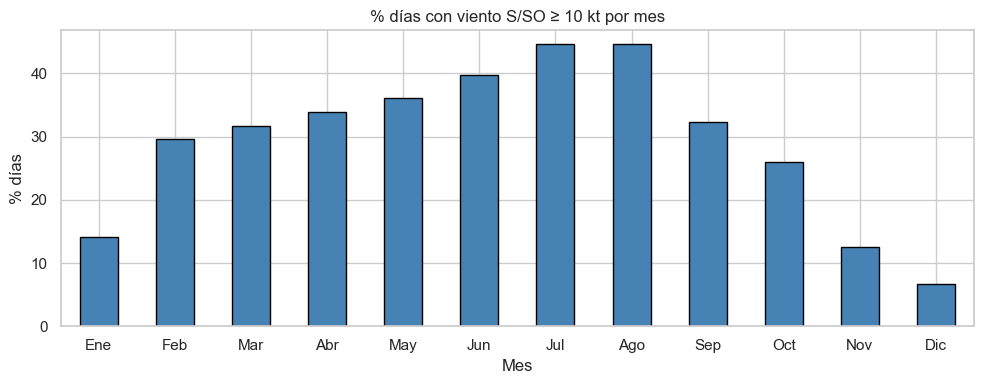

In [10]:
# 9.1 Frecuencia mensual de días térmicos
monthly_rate = (
    daily.groupby("month")["daily_target"]
    .mean()
    * 100
)

fig, ax = plt.subplots(figsize=(10, 4))
monthly_rate.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("% días con viento S/SO ≥ 10 kt por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("% días")
ax.set_xticklabels(
    ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"],
    rotation=0,
)
plt.tight_layout()
plt.show()


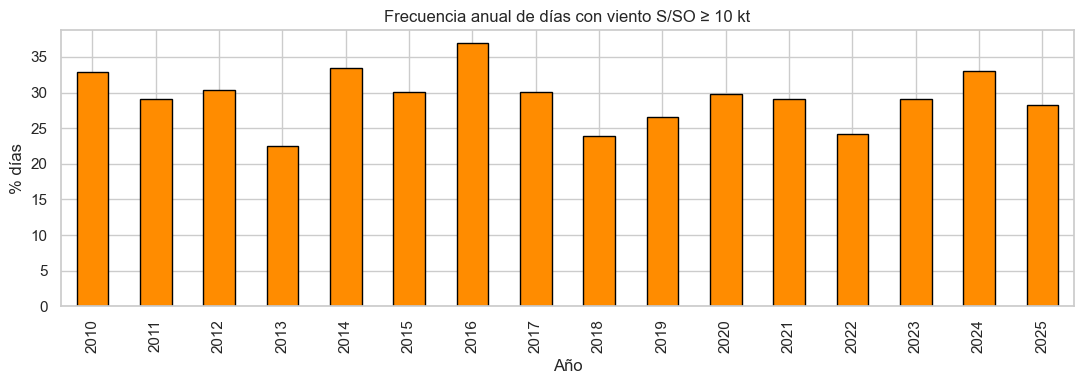

In [11]:
# 9.2 Frecuencia anual
annual_rate = daily["daily_target"].resample("YE").mean() * 100

fig, ax = plt.subplots(figsize=(11, 4))
annual_rate.index = annual_rate.index.year
annual_rate.plot(kind="bar", ax=ax, color="darkorange", edgecolor="black")
ax.set_title("Frecuencia anual de días con viento S/SO ≥ 10 kt")
ax.set_xlabel("Año")
ax.set_ylabel("% días")
plt.tight_layout()
plt.show()


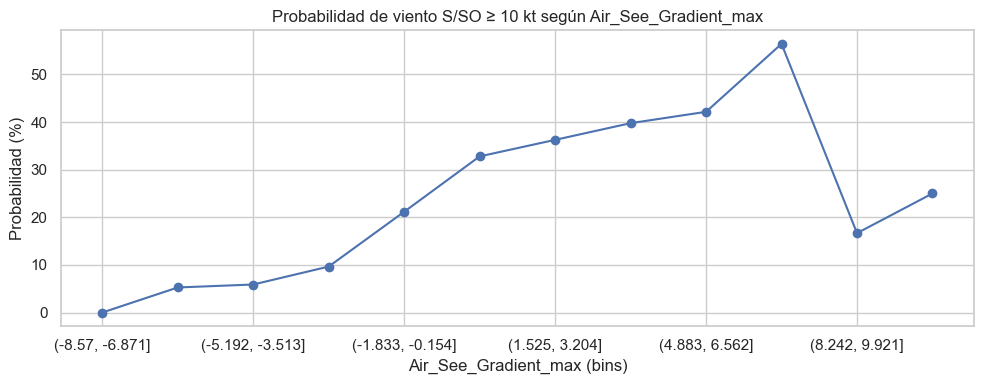

In [12]:
# 9.3 Gradiente aire-mar máximo vs probabilidad de evento
plot_df = daily.copy()
plot_df["gradient_bin"] = pd.cut(plot_df["Air_See_Gradient_max"], bins=12)
gradient_prob = plot_df.groupby("gradient_bin", observed=False)["daily_target"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
gradient_prob.plot(marker="o", ax=ax)
ax.set_title("Probabilidad de viento S/SO ≥ 10 kt según Air_See_Gradient_max")
ax.set_xlabel("Air_See_Gradient_max (bins)")
ax.set_ylabel("Probabilidad (%)")
ax.grid(True)
plt.tight_layout()
plt.show()


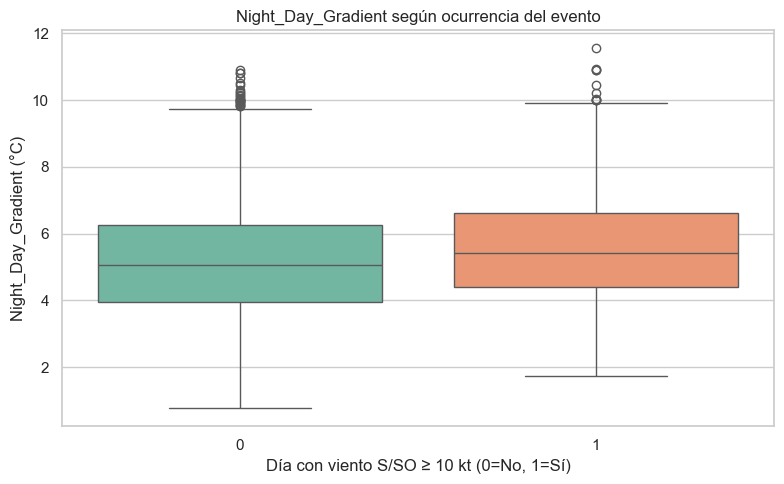

In [13]:
# 9.4 Night_Day_Gradient vs target
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=daily,
    x="daily_target",
    y="Night_Day_Gradient",
    hue="daily_target",
    palette="Set2",
    legend=False,
    ax=ax,
)
ax.set_title("Night_Day_Gradient según ocurrencia del evento")
ax.set_xlabel("Día con viento S/SO ≥ 10 kt (0=No, 1=Sí)")
ax.set_ylabel("Night_Day_Gradient (°C)")
plt.tight_layout()
plt.show()


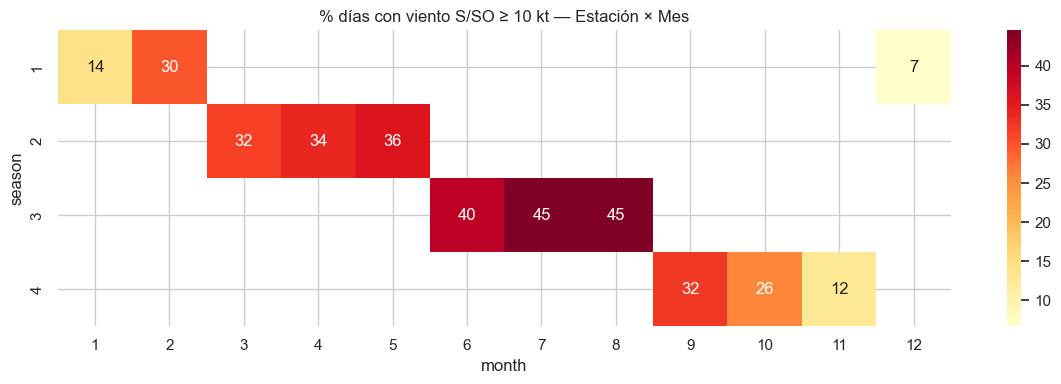

In [14]:
# 9.5 Heatmap mes × estación
heatmap_data = (
    daily.pivot_table(
        index="season",
        columns="month",
        values="daily_target",
        aggfunc="mean",
    )
    * 100
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax)
ax.set_title("% días con viento S/SO ≥ 10 kt — Estación × Mes")
plt.tight_layout()
plt.show()


### 10. Preparación del modelo

**Features para el Random Forest** (sin columnas de viento observado → evitamos leakage directo):

- `Night_Day_Gradient`
- `Irradiancia_solar_max`
- `Air_See_Gradient_max`
- `pressure_mean`, `precip_total`, `sst_mean`
- `month`, `day_of_year`, `season_code`

> **Nota honesta para la exposición:** estas features usan observaciones del **mismo día** (p.ej. irradiancia máxima). Eso sirve para **clasificar/analizar** patrones históricos, pero para una **previsión operativa a primera hora** habría que usar versiones retrasadas o datos de modelos meteorológicos. Lo comentamos en la presentación.


In [15]:
FEATURE_COLUMNS = [
    "Night_Day_Gradient",
    "Irradiancia_solar_max",
    "Air_See_Gradient_max",
    "pressure_mean",
    "precip_total",
    "sst_mean",
    "month",
    "day_of_year",
    "season_code",
]

model_df = daily.copy()
model_df["season_code"] = model_df["season"].astype("category").cat.codes

model_df = model_df.dropna(subset=FEATURE_COLUMNS + ["daily_target"]).copy()
print(f"Días disponibles para ML: {len(model_df):,}")


Días disponibles para ML: 5,806


### 11. Split temporal Train / Valid / Test


In [16]:
train = model_df.loc[:TRAIN_END]
valid = model_df.loc[VALID_START:VALID_END]
test = model_df.loc[TEST_START:]

print(f"Train: {len(train):,} días ({train.index.min().date()} → {train.index.max().date()})")
print(f"Valid: {len(valid):,} días ({valid.index.min().date()} → {valid.index.max().date()})")
print(f"Test:  {len(test):,} días ({test.index.min().date()} → {test.index.max().date()})")

TARGET = "daily_target"

X_train = train[FEATURE_COLUMNS]
y_train = train[TARGET]

X_valid = valid[FEATURE_COLUMNS]
y_valid = valid[TARGET]

X_test = test[FEATURE_COLUMNS]
y_test = test[TARGET]


Train: 4,345 días (2010-01-01 → 2021-12-31)
Valid: 730 días (2022-01-01 → 2023-12-31)
Test:  731 días (2024-01-01 → 2025-12-31)


### 12. Baseline (DummyClassifier)


In [17]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("=== BASELINE ===")
print(classification_report(y_test, y_pred_dummy, digits=3))


=== BASELINE ===
              precision    recall  f1-score   support

           0      0.694     1.000     0.819       507
           1      0.000     0.000     0.000       224

    accuracy                          0.694       731
   macro avg      0.347     0.500     0.410       731
weighted avg      0.481     0.694     0.568       731



/Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/03_Especialitzacio/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/03_Especialitzacio/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/03_Especialitzacio/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill

### 13. Random Forest


In [18]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST — TEST ===")
print(classification_report(y_test, y_pred, digits=3))
print(f"F1:  {f1_score(y_test, y_pred):.3f}")
print(f"AUC: {roc_auc_score(y_test, y_proba):.3f}")


=== RANDOM FOREST — TEST ===
              precision    recall  f1-score   support

           0      0.796     0.663     0.723       507
           1      0.447     0.616     0.518       224

    accuracy                          0.648       731
   macro avg      0.621     0.639     0.621       731
weighted avg      0.689     0.648     0.660       731

F1:  0.518
AUC: 0.714


### 14. Matriz de confusión


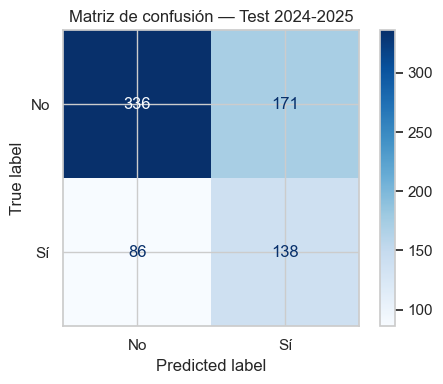

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No", "Sí"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Matriz de confusión — Test 2024-2025")
plt.tight_layout()
plt.show()


### 15. Curva ROC


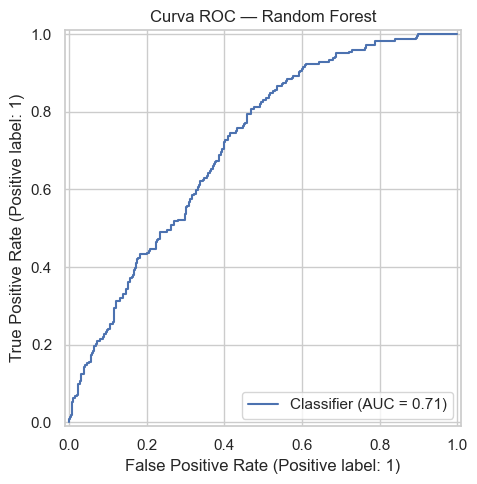

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax)
ax.set_title("Curva ROC — Random Forest")
plt.tight_layout()
plt.show()


### 16. Feature Importance


In [21]:
importance = (
    pd.Series(rf.feature_importances_, index=FEATURE_COLUMNS)
    .sort_values(ascending=False)
)

feature_ranking = importance.reset_index()
feature_ranking.columns = ["feature", "importance"]

feature_ranking


,feature,importance
0,Irradiancia_solar_max,0.230714
1,Air_See_Gradient_max,0.164546
2,Night_Day_Gradient,0.150294
3,day_of_year,0.136335
4,pressure_mean,0.119660
5,sst_mean,0.117240
6,month,0.035527
7,precip_total,0.033156
8,season_code,0.012528


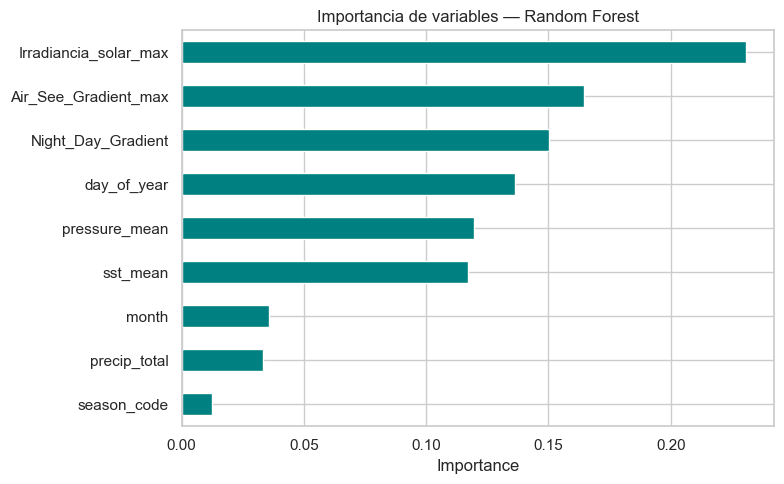

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
importance.sort_values().plot(kind="barh", ax=ax, color="teal")
ax.set_title("Importancia de variables — Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


In [23]:
import os
os.makedirs(REPORT_DIR, exist_ok=True)

feature_ranking.to_csv(
    f"{REPORT_DIR}/feature_importance_daily_ssw_model.csv",
    index=False,
)

print("Informe exportado correctamente.")


Informe exportado correctamente.


### 17. Validación (2022-2023)

Comprobamos que el modelo no memoriza solo el train.


In [24]:
y_valid_pred = rf.predict(X_valid)
y_valid_proba = rf.predict_proba(X_valid)[:, 1]

print("=== RANDOM FOREST — VALIDATION ===")
print(classification_report(y_valid, y_valid_pred, digits=3))
print(f"F1:  {f1_score(y_valid, y_valid_pred):.3f}")
print(f"AUC: {roc_auc_score(y_valid, y_valid_proba):.3f}")


=== RANDOM FOREST — VALIDATION ===
              precision    recall  f1-score   support

           0      0.822     0.621     0.708       536
           1      0.375     0.629     0.470       194

    accuracy                          0.623       730
   macro avg      0.599     0.625     0.589       730
weighted avg      0.703     0.623     0.645       730

F1:  0.470
AUC: 0.701


---

## Resumen

1. Dataset reducido a las variables acordadas.
2. Gradientes calculados correctamente a nivel diario.
3. Target: **¿hubo viento S/SO ≥ 10 kt?** (basado en sensor Buscaviento).
4. Random Forest con split temporal y métricas completas.

**Próximo paso sugerido (Día siguiente del bootcamp):** añadir previsión operativa usando solo datos disponibles a las 07:00 + forecasts GFS/Open-Meteo.
